# Oferta turística, temporada y licencias en Barcelona

Exploración sobre los marts de `housing` (ClickHouse local). Preguntas:

1. ¿Cómo evoluciona la oferta de Airbnb (anuncios, hosts, altas y bajas)?
2. ¿Se está desplazando la oferta hacia el alquiler de temporada (31+ noches) para esquivar la licencia turística y la ley de vivienda?
3. ¿Las licencias turísticas (HUTB) que declaran los anuncios existen en el registro municipal?
4. ¿Qué ha pasado con el alquiler €/m² antes y después del índice de referencia (marzo 2024)?
5. ¿Qué relación hay, por barrio, entre todo lo anterior?

**Fuentes**: Inside Airbnb (4 snapshots, sep-2025 → jun-2026), registro municipal de viviendas de uso turístico (Open Data BCN, 2020T4 → 2026), alquiler medio por barrio (Barcelona Dades, 2014 → 2026T1).

**Requisitos**: ClickHouse levantado (`docker compose up -d clickhouse`), pipeline construido (`dbt build`) y `pip install -r requirements-analysis.txt`.

In [1]:
import html
import json
import os
from pathlib import Path

import clickhouse_connect
import folium
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
# mismas credenciales que el pipeline (.env de la raíz), sin dependencia extra
for line in (ROOT / ".env").read_text().splitlines():
    if "=" in line and not line.startswith("#"):
        key, value = line.split("=", 1)
        os.environ.setdefault(key, value)

ch = clickhouse_connect.get_client(
    host=os.environ["CLICKHOUSE_HOST"],
    port=int(os.environ["CLICKHOUSE_PORT"]),
    username=os.environ["CLICKHOUSE_USER"],
    password=os.environ["CLICKHOUSE_PASSWORD"],
    database=os.environ.get("CLICKHOUSE_SCHEMA", "raw"),
)


def q(sql: str) -> pd.DataFrame:
    return ch.query_df(sql)


# estilo: marcas finas, rejilla y ejes recesivos, texto en tinta (no en color de serie)
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update(
    {
        "figure.figsize": (9, 3.6),
        "figure.dpi": 110,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": GRID,
        "axes.grid": True,
        "axes.grid.axis": "y",
        "axes.axisbelow": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "lines.linewidth": 2,
        "lines.markersize": 5,
        "text.color": INK,
        "axes.labelcolor": INK2,
        "axes.titlecolor": INK,
        "axes.titlesize": 11,
        "axes.titlelocation": "left",
        "xtick.color": INK2,
        "ytick.color": INK2,
        "legend.frameon": False,
        "font.size": 9,
    }
)
pd.options.display.float_format = "{:,.1f}".format

## 1. Oferta de Airbnb

"Parque" aquí = anuncios **de Airbnb** publicados por Inside Airbnb en cada snapshot. No incluye otras plataformas ni el alquiler de larga duración.

Un **host** es la cuenta de anfitrión en Airbnb (`host_id`), no necesariamente el propietario: con 10+ anuncios suele ser una gestora profesional.

In [2]:
snap = q("select snapshot_date, listing_id, host_id from fct_listing_snapshot")
dates = sorted(snap.snapshot_date.unique())
ids = {d: set(snap.listing_id[snap.snapshot_date == d]) for d in dates}

por_host = snap.groupby(["snapshot_date", "host_id"]).size().rename("n").reset_index()
parque = pd.DataFrame(
    {
        "anuncios": [len(ids[d]) for d in dates],
        "hosts": por_host.groupby("snapshot_date").size().values,
        "altas": [None] + [len(ids[b] - ids[a]) for a, b in zip(dates, dates[1:])],
        "bajas": [None] + [len(ids[a] - ids[b]) for a, b in zip(dates, dates[1:])],
        "% anuncios de hosts con 10+": por_host.assign(big=por_host.n >= 10)
        .groupby("snapshot_date")
        .apply(lambda g: g.n[g.big].sum() / g.n.sum() * 100, include_groups=False)
        .values,
    },
    index=pd.Index(dates, name="snapshot"),
)
parque

,anuncios,hosts,altas,bajas,% anuncios de hosts con 10+
snapshot,,,,,
2025-09-14,19410,6620,NaN,NaN,46.9
2025-12-14,18177,5776,"2,149.0","3,382.0",49.5
2026-03-21,16107,5238,"1,168.0","3,238.0",48.3
2026-06-24,15293,4595,"2,378.0","3,192.0",50.0


## 2. Licencias declaradas: temporada vs licencia turística

Cada anuncio se clasifica según su licencia declarada, cruzada con el registro municipal vigente en esa fecha (`fct_listing_license`):

| Categoría | Criterio |
|---|---|
| Licencia turística válida | HUTB en el registro y en el mismo barrio, u otro establecimiento turístico registrado (hotel `HB`, apartamento turístico `ATB`, albergue `AJ`…) |
| HUTB inexistente | nº 0 o mayor que el máximo emitido por la Generalitat (`HUTB-079999`) |
| Temporada (31+ noches) | sin licencia turística y estancia mínima de 31 noches o más |
| HUTB no registrado en BCN / otra dirección | nº válido que no está en el registro de Barcelona, o que está en otro barrio |
| Corta estancia sin licencia turística | estancia mínima < 31 noches y sin licencia turística |

In [3]:
MAX_HUTB = 79_999  # máximo nº HUTB emitido (registro de la Generalitat, sep-2026)
ESTABLECIMIENTO = r"Regional registration number<br />(HB|HS|H|ATB|AJ|LLB|PB)-?\\d"

CATEGORIA_SQL = f"""
multiIf(
    license_type = 'hutb' and hutb_en_registro and hutb_mismo_barrio,
        'Licencia turística válida',
    license_type != 'hutb' and match(license, '{ESTABLECIMIENTO}'),
        'Licencia turística válida',
    license_type = 'hutb' and (hutb_num = 0 or hutb_num > {MAX_HUTB}),
        'HUTB inexistente',
    license_type != 'hutb' and minimum_nights >= 31,
        'Temporada (31+ noches)',
    license_type = 'hutb',
        'HUTB no registrado en BCN / otra dirección',
    'Corta estancia sin licencia turística'
)
"""
CATEGORIAS = [
    "Licencia turística válida",
    "HUTB inexistente",
    "Temporada (31+ noches)",
    "HUTB no registrado en BCN / otra dirección",
    "Corta estancia sin licencia turística",
]
# paleta categórica en orden fijo, validada (CVD y visión normal) con el
# validador de la skill dataviz; 3 colores < 3:1 sobre blanco -> leyenda + tabla
COLOR = dict(zip(CATEGORIAS, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]))

lic = q(f"select snapshot_date, {CATEGORIA_SQL} as categoria from fct_listing_license")
composicion = pd.crosstab(lic.snapshot_date, lic.categoria)[CATEGORIAS]
pct = composicion.div(composicion.sum(axis=1), axis=0) * 100
display(composicion)
pct

categoria,Licencia turística válida,HUTB inexistente,Temporada (31+ noches),HUTB no registrado en BCN / otra dirección,Corta estancia sin licencia turística
snapshot_date,,,,,
2025-09-14,3652,1485,7102,1699,5472
2025-12-14,4776,1804,6869,1807,2921
2026-03-21,4589,1689,5459,1837,2533
2026-06-24,4695,1808,5447,1806,1537


categoria,Licencia turística válida,HUTB inexistente,Temporada (31+ noches),HUTB no registrado en BCN / otra dirección,Corta estancia sin licencia turística
snapshot_date,,,,,
2025-09-14,18.8,7.7,36.6,8.8,28.2
2025-12-14,26.3,9.9,37.8,9.9,16.1
2026-03-21,28.5,10.5,33.9,11.4,15.7
2026-06-24,30.7,11.8,35.6,11.8,10.1


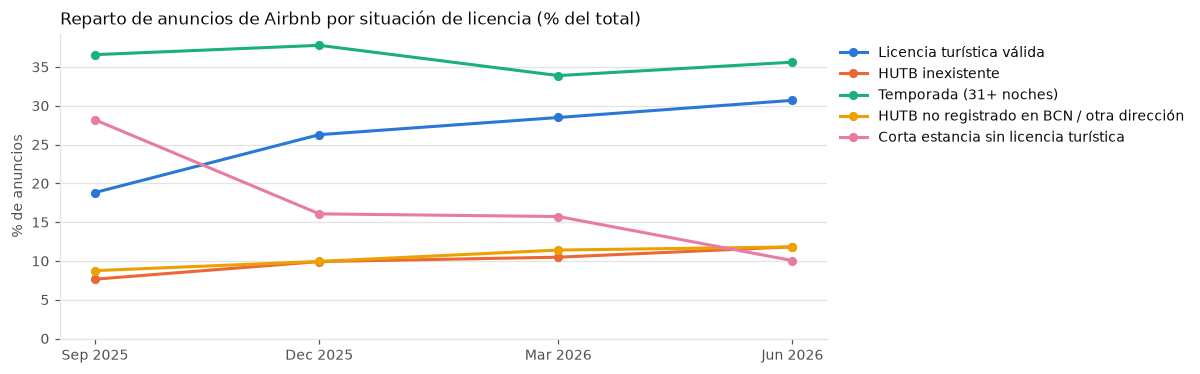

In [4]:
fig, ax = plt.subplots()
for cat in CATEGORIAS:
    ax.plot(pct.index, pct[cat], marker="o", color=COLOR[cat], label=cat)
ax.set_title("Reparto de anuncios de Airbnb por situación de licencia (% del total)")
ax.set_ylabel("% de anuncios")
ax.set_ylim(0, None)
ax.set_xticks(pct.index, [d.strftime("%b %Y") for d in pct.index])
ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.show()

### 2.1 ¿Qué pasa con cada anuncio entre sep-2025 y jun-2026?

Mismo anuncio (`listing_id`) en el primer y el último snapshot. Filas = categoría en sep-2025, columnas = categoría en jun-2026; "Desaparecido" = ya no está en Airbnb.

In [5]:
trans = q(f"""
with c as (select listing_id, snapshot_date, {CATEGORIA_SQL} as categoria from fct_listing_license)
select a.categoria as sep_2025, if(b.listing_id = 0, 'Desaparecido', b.categoria) as jun_2026,
       count() as anuncios
from (select * from c where snapshot_date = '2025-09-14') as a
left join (select * from c where snapshot_date = '2026-06-24') as b
    on a.listing_id = b.listing_id
group by sep_2025, jun_2026
""")
trans.pivot_table(
    index="sep_2025", columns="jun_2026", values="anuncios", fill_value=0
).reindex(index=CATEGORIAS, columns=CATEGORIAS + ["Desaparecido"], fill_value=0)

jun_2026,Licencia turística válida,HUTB inexistente,Temporada (31+ noches),HUTB no registrado en BCN / otra dirección,Corta estancia sin licencia turística,Desaparecido
sep_2025,,,,,,
Licencia turística válida,"3,167.0",28.0,3.0,34.0,9.0,411.0
HUTB inexistente,40.0,999.0,2.0,6.0,1.0,437.0
Temporada (31+ noches),3.0,19.0,"3,975.0",17.0,197.0,"2,891.0"
HUTB no registrado en BCN / otra dirección,42.0,9.0,0.0,"1,357.0",1.0,290.0
Corta estancia sin licencia turística,884.0,28.0,369.0,50.0,"1,039.0","3,102.0"


### 2.2 Licencias HUTB compartidas por varios anuncios

Cada HUTB corresponde a **una** vivienda. Patrones cuando un mismo nº aparece en varios anuncios (último snapshot). Las coordenadas de Inside Airbnb están desplazadas hasta ~150 m por anonimización: "mismo edificio" es aproximado.

In [6]:
compartidas = q("""
with l as (
    select f.hutb_num, f.host_id, f.room_type, s.longitude, s.latitude
    from fct_listing_license as f
    inner join fct_listing_snapshot as s
        on f.listing_id = s.listing_id and f.snapshot_date = s.snapshot_date
    where f.snapshot_date = (select max(snapshot_date) from fct_listing_license)
      and f.license_type = 'hutb'
),
g as (
    select
        hutb_num,
        count() as n,
        uniqExact(host_id) as hosts,
        countIf(room_type = 'Entire home/apt') as enteros,
        greatCircleDistance(min(longitude), min(latitude), max(longitude), max(latitude))
            as dist_m
    from l
    group by hutb_num
    having n > 1
)
select
    multiIf(
        hutb_num = 0 or hutb_num > 79999, '1. Nº inexistente',
        hosts > 1 and dist_m > 1000, '2. Varios hosts a más de 1 km (copiada)',
        hosts = 1 and dist_m <= 350 and enteros >= 2,
            '3. Mismo host, varios pisos enteros en el mismo edificio',
        hosts > 1 and dist_m <= 350, '4. Varios hosts, mismo sitio (¿mismo piso duplicado?)',
        enteros <= 1, '5. Habitaciones del mismo piso (plausible)',
        '6. Otros'
    ) as patron,
    count() as licencias,
    sum(n) as anuncios
from g
group by patron
order by patron
""")
compartidas

,patron,licencias,anuncios
0,1. Nº inexistente,81,283
1,2. Varios hosts a más de 1 km (copiada),70,182
2,"3. Mismo host, varios pisos enteros en el mism...",127,383
3,"4. Varios hosts, mismo sitio (¿mismo piso dupl...",200,546
4,5. Habitaciones del mismo piso (plausible),17,56
5,6. Otros,27,92


## 3. Registro municipal de viviendas de uso turístico

Nº de licencias HUT vigentes en cada trimestre publicado. Faltan 2024T1-T2 (sin nº HUTB o sin fichero) y 2023 tiene algún trimestre reconstruido de CSV mal formados (ver `progress.md`).

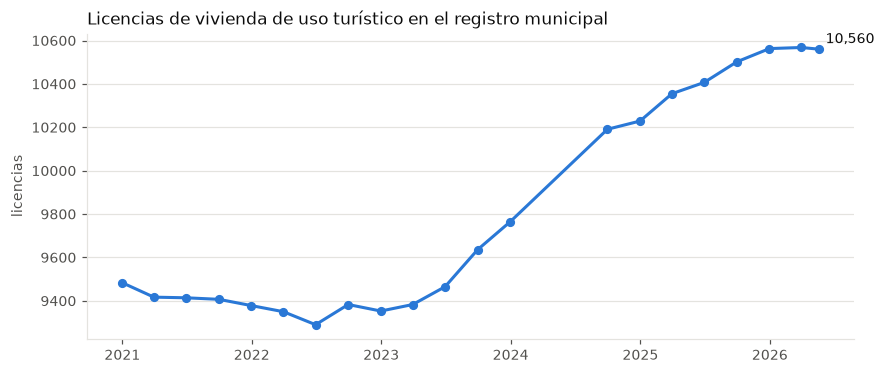

,licencias,plazas
snapshot_date,,
2020-12-31,9484,58026
2021-03-31,9417,57637
2021-06-30,9414,57517
2021-09-30,9407,57479
2021-12-31,9378,57299
2022-03-31,9350,57095
2022-06-30,9290,56678
2022-09-30,9383,56736
2022-12-31,9353,56557


In [7]:
registro = q("""
select snapshot_date, count() as licencias, sum(plazas) as plazas
from fct_hut_registry group by snapshot_date order by snapshot_date
""").set_index("snapshot_date")

fig, ax = plt.subplots()
ax.plot(registro.index, registro.licencias, marker="o", color="#2a78d6")
ax.set_title("Licencias de vivienda de uso turístico en el registro municipal")
ax.set_ylabel("licencias")
last = registro.iloc[-1]
ax.annotate(
    f"{last.licencias:,.0f}",
    (registro.index[-1], last.licencias),
    xytext=(4, 4),
    textcoords="offset points",
    color=INK,
)
plt.show()
registro

## 4. Alquiler de larga duración (€/m²)

Media simple de los barrios (no ponderada por nº de contratos). La línea vertical marca la entrada en vigor del índice de referencia de precios en zona tensionada (marzo 2024). Comparar el crecimiento anual medio de los 2 años anteriores con los 2 posteriores es **descriptivo**: no aísla el efecto de la regulación de otros factores.

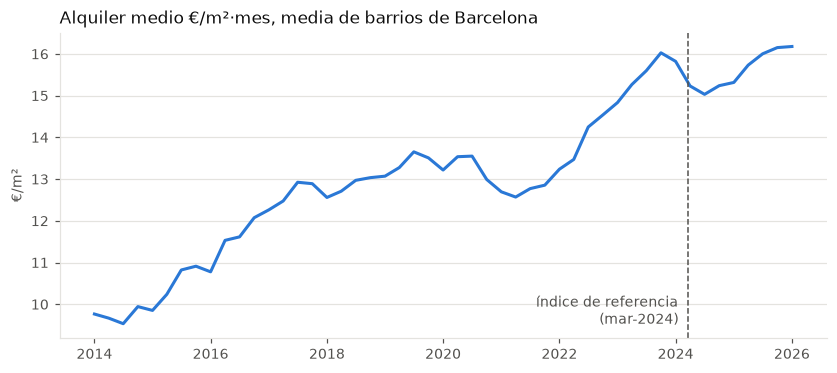

Ciudad: 9.3 %/año antes, 1.1 %/año después


,€/m² 2026T1,crec. anual 2022T1→2024T1 (%),crec. anual 2024T1→2026T1 (%)
barrio_label,,,
la Barceloneta,23.2,0.8,3.6
Diagonal Mar i el Front Marítim del Poblenou,21.2,13.6,4.7
Pedralbes,20.9,15.1,3.8
les Tres Torres,20.4,5.7,1.7
la Vila Olímpica del Poblenou,19.7,8.7,-3.9
Sarrià,19.5,8.0,-2.2
"Sant Pere, Santa Caterina i la Ribera",19.2,7.1,4.7
Sant Gervasi - la Bonanova,19.0,11.8,3.3
la Bordeta,18.9,22.0,1.6


In [8]:
rent = q("""
select r.quarter_start, r.barrio_id, g.barrio_label, r.rent_price_per_m2
from fct_rent_quarter as r
left join dim_geography as g on r.barrio_id = g.barrio_id
where r.rent_price_per_m2 is not null
""")
ciudad = rent.groupby("quarter_start").rent_price_per_m2.mean()

REGULACION = pd.Timestamp("2024-03-16")
fig, ax = plt.subplots()
ax.plot(ciudad.index, ciudad.values, color="#2a78d6")
ax.axvline(REGULACION, color=INK2, linewidth=1, linestyle="--")
ax.annotate(
    "índice de referencia\n(mar-2024)",
    (REGULACION, ciudad.min()),
    xytext=(-6, 0),
    textcoords="offset points",
    ha="right",
    color=INK2,
)
ax.set_title("Alquiler medio €/m²·mes, media de barrios de Barcelona")
ax.set_ylabel("€/m²")
plt.show()


def cagr(s: pd.Series, start: str, end: str) -> float:
    a, b = s.get(pd.Timestamp(start)), s.get(pd.Timestamp(end))
    return ((b / a) ** 0.5 - 1) * 100 if a and b else float("nan")


piv = rent.pivot_table(
    index="barrio_label", columns="quarter_start", values="rent_price_per_m2"
)
antes_despues = pd.DataFrame(
    {
        "€/m² 2026T1": piv[pd.Timestamp("2026-01-01")],
        "crec. anual 2022T1→2024T1 (%)": piv.apply(
            cagr, axis=1, args=("2022-01-01", "2024-01-01")
        ),
        "crec. anual 2024T1→2026T1 (%)": piv.apply(
            cagr, axis=1, args=("2024-01-01", "2026-01-01")
        ),
    }
).dropna()
print(
    "Ciudad:",
    f"{cagr(ciudad, '2022-01-01', '2024-01-01'):.1f} %/año antes,",
    f"{cagr(ciudad, '2024-01-01', '2026-01-01'):.1f} %/año después",
)
antes_despues.sort_values("€/m² 2026T1", ascending=False).head(10)

## 5. Cruce por barrio

Último trimestre con ambas fuentes: alquiler 2026T1, anuncios del snapshot 2026-03-21, registro vigente en esa fecha. Correlación de Spearman (rangos) sobre ~70 barrios: **asociación, no causalidad**, y los barrios céntricos concentran a la vez turismo y precios altos.

In [9]:
por_barrio = q(f"""
with l as (
    select barrio_id, {CATEGORIA_SQL} as categoria
    from fct_listing_license where snapshot_date = '2026-03-21'
),
reg as (
    select barrio_id, count() as licencias_registro
    from fct_hut_registry where snapshot_date = '2025-12-31'
    group by barrio_id
)
select
    g.barrio_label as barrio,
    r.rent_price_per_m2 as eur_m2,
    count() as anuncios,
    countIf(categoria = 'Temporada (31+ noches)') / count() * 100 as pct_temporada,
    countIf(categoria in ('HUTB inexistente', 'HUTB no registrado en BCN / otra dirección',
                          'Corta estancia sin licencia turística')) / count() * 100
        as pct_irregular,
    any(reg.licencias_registro) as licencias_registro
from l
left join dim_geography as g on l.barrio_id = g.barrio_id
left join fct_rent_quarter as r on l.barrio_id = r.barrio_id and r.quarter_start = '2026-01-01'
left join reg on l.barrio_id = reg.barrio_id
group by barrio, eur_m2
having anuncios >= 30
""").set_index("barrio")
por_barrio["anuncios_por_licencia"] = (
    por_barrio.anuncios / por_barrio.licencias_registro
)

display(por_barrio.corr(method="spearman")[["eur_m2"]].drop("eur_m2").round(2))
por_barrio.sort_values("pct_temporada", ascending=False).head(10)

,eur_m2
anuncios,0.2
pct_temporada,0.0
pct_irregular,-0.3
licencias_registro,0.3
anuncios_por_licencia,-0.2


,eur_m2,anuncios,pct_temporada,pct_irregular,licencias_registro,anuncios_por_licencia
barrio,,,,,,
la Barceloneta,23.2,426,62.2,26.5,85,5.0
Sant Andreu,14.7,82,61.0,24.4,32,2.6
la Marina de Port,14.1,60,58.3,35.0,8,7.5
Sant Gervasi - Galvany,18.4,509,52.8,24.4,306,1.7
la Salut,18.0,73,52.1,38.4,37,2.0
Sarrià,19.5,58,51.7,22.4,29,2.0
el Carmel,14.0,58,51.7,17.2,34,1.7
Vallcarca i els Penitents,15.3,81,50.6,35.8,39,2.1
Sants - Badal,17.2,173,50.3,33.5,109,1.6


## 6. Mapa de anuncios (snapshot 2026-06-24)

Cada punto es un anuncio, coloreado por situación de licencia. Click → condiciones del anuncio. En el centro los puntos se solapan y la última capa tapa a las anteriores: activa/desactiva capas en el control de la derecha para ver cada categoría. Se guarda también en `notebooks/output/mapa_licencias.html` para abrirlo en el navegador.

In [10]:
mapa_df = q(f"""
with lic as (
    select *, {CATEGORIA_SQL} as categoria
    from fct_listing_license where snapshot_date = '2026-06-24'
),
host_size as (
    select host_id, count() as anuncios_host
    from fct_listing_snapshot where snapshot_date = '2026-06-24' group by host_id
)
select
    -- alias explícitos: tras un JOIN ClickHouse 24.8 devuelve 'tabla.col'
    f.listing_id as listing_id,
    s.latitude as latitude,
    s.longitude as longitude,
    st.name as name,
    g.barrio_label as barrio_label,
    f.room_type as room_type,
    f.accommodates as accommodates,
    f.minimum_nights as minimum_nights,
    s.price as price,
    f.license as license,
    f.hutb_num as hutb_num,
    f.hutb_en_registro as hutb_en_registro,
    f.hutb_plazas_registro as hutb_plazas_registro,
    f.hutb_distancia_m as hutb_distancia_m,
    f.n_anuncios_misma_licencia as n_anuncios_misma_licencia,
    f.n_hosts_misma_licencia as n_hosts_misma_licencia,
    f.host_id as host_id,
    h.anuncios_host as anuncios_host,
    f.categoria as categoria
from lic as f
inner join fct_listing_snapshot as s
    on f.listing_id = s.listing_id and f.snapshot_date = s.snapshot_date
left join stg_airbnb__listings as st
    on f.listing_id = st.listing_id and f.snapshot_date = st._snapshot_date
left join dim_geography as g on f.barrio_id = g.barrio_id
left join host_size as h on f.host_id = h.host_id
where s.latitude is not null
""")


def fmt(v, suffix=""):
    return "—" if pd.isna(v) else f"{v:,.0f}{suffix}"


def licencia_corta(lic) -> str:
    """'Spain - National ...<br />X<br /><br />Barcelona - Regional ...<br />Y' -> 'X · Y'"""
    if not lic:
        return "—"
    partes = [
        p for p in str(lic).split("<br />") if p and "registration number" not in p
    ]
    return html.escape(" · ".join(partes))[:90]


def props(r) -> dict:
    """Solo datos (el popup lo monta folium como tabla): mantiene el HTML ligero."""
    p = {
        "Anuncio": f"<a href='https://www.airbnb.com/rooms/{r.listing_id}' target='_blank'>"
        f"{html.escape(str(r.name or r.listing_id))[:60]}</a>",
        "Barrio": r.barrio_label,
        "Tipo": r.room_type,
        "Precio/noche": fmt(r.price, " $"),
        "Noches mín.": fmt(r.minimum_nights),
        "Plazas": fmt(r.accommodates),
        "Licencia": licencia_corta(r.license),
        "Situación": r.categoria,
        "Anuncios del host": fmt(r.anuncios_host),
    }
    if not pd.isna(r.hutb_num):
        p |= {
            "HUTB en registro": "sí" if r.hutb_en_registro else "no",
            "Plazas registro": fmt(r.hutb_plazas_registro),
            "Distancia registro": fmt(r.hutb_distancia_m, " m"),
            "Anuncios mismo HUTB": fmt(r.n_anuncios_misma_licencia),
            "Hosts mismo HUTB": fmt(r.n_hosts_misma_licencia),
        }
    return p


CAMPOS = [
    "Anuncio",
    "Barrio",
    "Tipo",
    "Precio/noche",
    "Noches mín.",
    "Plazas",
    "Licencia",
    "Situación",
    "HUTB en registro",
    "Plazas registro",
    "Distancia registro",
    "Anuncios mismo HUTB",
    "Hosts mismo HUTB",
    "Anuncios del host",
]
CAMPOS_HUTB = {
    "HUTB en registro",
    "Plazas registro",
    "Distancia registro",
    "Anuncios mismo HUTB",
    "Hosts mismo HUTB",
}


# teselas grises neutras y sin API key (las de CARTO ya la piden)
m = folium.Map(location=[41.395, 2.165], zoom_start=13, tiles="Esri.WorldGrayCanvas")
barrios = json.loads(
    (ROOT / "data/landing/airbnb/2026-06-24/neighbourhoods.geojson").read_text(
        encoding="utf-8"
    )
)
folium.GeoJson(
    barrios,
    name="Barrios",
    style_function=lambda _: {"color": INK2, "weight": 0.6, "fillOpacity": 0},
    tooltip=folium.GeoJsonTooltip(fields=["neighbourhood"], labels=False),
).add_to(m)
# una capa GeoJSON por categoría (no un CircleMarker por anuncio): el HTML pasa
# de ~35 MB a unos pocos, porque folium no genera JS por cada punto.
for cat in CATEGORIAS:
    sub = mapa_df[mapa_df.categoria == cat]
    campos = (
        CAMPOS
        if sub.hutb_num.notna().any()
        else [c for c in CAMPOS if c not in CAMPOS_HUTB]
    )
    features = [
        {
            "type": "Feature",
            "geometry": {"type": "Point", "coordinates": [r.longitude, r.latitude]},
            "properties": {c: props(r).get(c, "—") for c in campos},
        }
        for r in sub.itertuples()
    ]
    folium.GeoJson(
        {"type": "FeatureCollection", "features": features},
        name=f"<span style='color:{COLOR[cat]}'>●</span> {cat} ({len(sub):,})",
        # anillo blanco (color de la superficie) entre puntos solapados
        marker=folium.CircleMarker(
            radius=4,
            color="#ffffff",
            weight=1,
            fill=True,
            fill_color=COLOR[cat],
            fill_opacity=0.9,
        ),
        popup=folium.GeoJsonPopup(fields=campos, max_width=360),
    ).add_to(m)
folium.LayerControl(collapsed=False).add_to(m)

(ROOT / "notebooks/output").mkdir(exist_ok=True)
m.save(ROOT / "notebooks/output/mapa_licencias.html")
m

(mapa omitido del notebook versionado: ejecuta la celda o abre notebooks/output/mapa_licencias.html)


## 7. Conclusiones

Con datos a 2026-06-24. Airbnb solo tiene 4 snapshots (9 meses): las tendencias de Airbnb son de corto plazo.

**1. La oferta de Airbnb se contrae y se profesionaliza.** Los anuncios caen un 21 % (19.410 → 15.293) y los hosts un 31 % (6.620 → 4.595). Cada trimestre salen unos 3.200 anuncios y entran entre 1.200 y 2.400. La cuota de anuncios de hosts con 10 o más sube del 47 % al 50 %: salen sobre todo particulares y quedan las gestoras.

**2. La temporada es grande pero no crece en este periodo.** Ronda el 35 % de la oferta (unos 5.400 anuncios), fuera del régimen de licencia turística. El desplazamiento neto de corta estancia a temporada es pequeño: 369 anuncios pasan a temporada y 197 hacen el camino inverso. La hipótesis de que el mercado se está moviendo hacia la temporada **no se ve en estos 9 meses**. Sin histórico de Airbnb anterior a sep-2025 no se puede saber si el desplazamiento ocurrió antes (ley de vivienda 2023, índice de referencia 2024).

**3. La corta estancia sin licencia cae con fuerza, pero crecen las licencias dudosas.** Pasa del 28 % al 10 %. De los anuncios de sep-2025 en esa situación, el 57 % ha desaparecido y 884 pasan a declarar un HUTB válido. En cambio, el 23,6 % de los anuncios de jun-2026 declara un HUTB **inexistente** (1.808) o **no registrado en Barcelona** (1.806), y la proporción sube. Además, 200 números HUTB aparecen en anuncios de varios hosts en el mismo sitio, y 127 los usa un mismo host para varios pisos enteros de un edificio, cuando cada HUTB corresponde a una sola vivienda.

**4. El registro municipal crece.** Pasa de 9.484 licencias (2020T4) a 10.560 (may-2026), un 11 % más, y el crecimiento se concentra desde 2023. Choca con la moratoria de nuevas HUT en Barcelona: queda pendiente averiguar el motivo (regularizaciones, altas de expedientes antiguos…).

**5. El alquiler €/m² se frena después de marzo de 2024.** La media de barrios crecía un 9,3 % anual entre 2022T1 y 2024T1, y un 1,1 % anual entre 2024T1 y 2026T1. Aun así, en 2026T1 supera el máximo de 2023. Es un dato descriptivo: no aísla el efecto de la regulación.

**6. Por barrio, la oferta turística apenas se asocia con el precio.** Las correlaciones con €/m² son débiles (|ρ| ≤ 0,3) y la del % de temporada es nula. En un corte de unos 70 barrios no se sostiene que el volumen de temporada o de irregularidad explique el precio del alquiler. La concentración sí es muy desigual: en la Barceloneta el 62 % de la oferta es de temporada.

### Recomendaciones

1. **Priorizar la inspección con `fct_listing_license`.** Hay 1.808 anuncios con HUTB inexistente y 546 que comparten HUTB con otro host en el mismo sitio. Es una lista accionable, con enlace al anuncio desde el mapa.
2. **Vigilar la temporada por barrio y cruzarla con el registro nacional (ESFCNT).** Es un tercio de la oferta, sin control de licencia turística, y en algunos barrios (Barceloneta, Sant Gervasi - Galvany) supera el 50 %.
3. **Completar los datos antes de sacar conclusiones causales.** Pedir a Inside Airbnb los snapshots anteriores a sep-2025 (para ver el efecto de la ley de vivienda y del índice de referencia) y añadir el nº de contratos de alquiler de larga duración (para tener volumen, no solo precio).